<a href="https://colab.research.google.com/github/dai-fujiden/boite-a-jouets/blob/main/phono_chine/Zhongwen_yinjie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Visit the website  Unicode https://home.unicode.org/

### 2. Unihan database explanation  https://www.unicode.org/reports/tr38/ . Reach the hyperlinked text, the UCD (the Unicode Character Database).


### 3. search the following texts using `ctrl+F` and click here.
```
Unihan Database
Latest version:
https://www.unicode.org/Public/UCD/latest/ucd/Unihan.zip
Version 17.0.0:
https://www.unicode.org/Public/17.0.0/ucd/Unihan.zip
```

In [262]:
!pip install japanize-matplotlib

In [280]:
!git clone https://github.com/cmu-llab/wikihan.git

!git clone https://github.com/unicode-org/unihan-database.git

fatal: destination path 'wikihan' already exists and is not an empty directory.
Cloning into 'unihan-database'...
remote: Enumerating objects: 2056, done.
remote: Counting objects: 100% (1343/1343), done.
remote: Compressing objects: 100% (973/973), done.
remote: Total 2056 (delta 767), reused 370 (delta 370), pack-reused 713 (from 2)
Receiving objects: 100% (2056/2056), 3.53 MiB | 16.80 MiB/s, done.
Resolving deltas: 100% (1346/1346), done.


In [263]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib
japanize_matplotlib.japanize()
rows = []

with open("Unihan_Readings.txt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("#"):
            continue

        cols = line.strip().split("\t")

        if len(cols) != 3:
            continue

        code, field, value = cols

        if field != "kMandarin":
            continue

        cp = int(code[2:], 16)
        hanzi = chr(cp)

        for pinyin in value.split():
            rows.append([hanzi, pinyin])

df = pd.DataFrame(rows, columns=["漢字", "ピンイン"])

df.to_csv("unihan_pinyin.csv", index=False, encoding="utf-8-sig")

In [264]:
df

,漢字,ピンイン
0,㐀,qiū
1,㐁,tiàn
2,㐄,kuà
3,㐅,wǔ
4,㐆,yǐn
...,...,...
44444,𲍿,yè
44445,𲎅,chì
44446,𲎆,tóng
44447,𲎈,méng


In [265]:
import pandas as pd
import re

INITIALS = [
    "zh","ch","sh",
    "b","p","m","f",
    "d","t","n","l",
    "g","k","h",
    "j","q","x",
    "r","z","c","s",
    "y","w"
]

TONE_MAP = {
    "ā":("a",1),"á":("a",2),"ǎ":("a",3),"à":("a",4),
    "ē":("e",1),"é":("e",2),"ě":("e",3),"è":("e",4),
    "ī":("i",1),"í":("i",2),"ǐ":("i",3),"ì":("i",4),
    "ō":("o",1),"ó":("o",2),"ǒ":("o",3),"ò":("o",4),
    "ū":("u",1),"ú":("u",2),"ǔ":("u",3),"ù":("u",4),
    "ǖ":("ü",1),"ǘ":("ü",2),"ǚ":("ü",3),"ǜ":("ü",4),
}

def parse_pinyin(py):
    tone = 5

    plain = ""

    for ch in py:
        if ch in TONE_MAP:
            base, tone = TONE_MAP[ch]
            plain += base
        else:
            plain += ch

    initial = ""

    for ini in sorted(INITIALS, key=len, reverse=True):
        if plain.startswith(ini):
            initial = ini
            break

    final = plain[len(initial):]

    return pd.Series([
        initial,
        final,
        tone
    ])

df[["consonants","vowel","tone"]] = df["ピンイン"].apply(parse_pinyin)

print(df.head())

  漢字  ピンイン consonants vowel  tone
0  㐀   qiū          q    iu     1
1  㐁  tiàn          t   ian     4
2  㐄   kuà          k    ua     4
3  㐅    wǔ          w     u     3
4  㐆   yǐn          y    in     3


In [267]:
df_mid = pd.read_csv("wikihan/data/MC/mc-pron-baxter.csv")

In [268]:
df_mid[["middle_pronounce", "middle_tone"]] = df_mid.iloc[:, 2].str.split(' ', n=2, expand=True)
df_mid["middle_tone"] = df_mid["middle_tone"].str[0]

In [269]:
# 平 = 1, 上 = 2, 去 = 3, 入 = 4とする
df_mid.loc[df_mid["middle_tone"] == "平", "middle_tone2"] = 1
df_mid.loc[df_mid["middle_tone"] == "上", "middle_tone2"] = 2
df_mid.loc[df_mid["middle_tone"] == "去", "middle_tone2"] = 3
df_mid.loc[df_mid["middle_tone"] == "入", "middle_tone2"] = 4
df_mid = df_mid.rename(columns={df_mid.columns[0]: "漢字"})

df_mid.head()

,漢字,5611001,影眞三開 入於悉,ʔit⁴,ʔit⁴.1,middle_pronounce,middle_tone,middle_tone2
0,丁,5611004,知耕二開 平中莖,trɛng¹,ʈɛŋ¹,知耕二開,平,1.0
1,丂,5611009,溪豪一開 上苦浩,khaw²,kʰaw²,溪豪一開,上,2.0
2,七,5611012,清眞三開 入親吉,tshit⁴,t͡sʰit⁴,清眞三開,入,4.0
3,丄,5611016,常陽三開 上時掌,dzyang²,d͡ʑaŋ²,常陽三開,上,2.0
4,丅,5611020,匣麻二開 上胡雅,hæ²,ɣæ²,匣麻二開,上,2.0


In [270]:
#同じ漢字が対応するように二つのデータフレーム dfとdf_midを合体。
df = pd.merge(df, df_mid[["漢字", "middle_pronounce", "middle_tone"]], on="漢字", how="left")
df.head()

,漢字,ピンイン,consonants,vowel,tone,middle_pronounce,middle_tone
0,㐀,qiū,q,iu,1,NaN,NaN
1,㐁,tiàn,t,ian,4,透覃一開,去
2,㐄,kuà,k,ua,4,NaN,NaN
3,㐅,wǔ,w,u,3,NaN,NaN
4,㐆,yǐn,y,in,3,影微三開,平


In [271]:
df = df.dropna()
df.head()

,漢字,ピンイン,consonants,vowel,tone,middle_pronounce,middle_tone
1,㐁,tiàn,t,ian,4,透覃一開,去
4,㐆,yǐn,y,in,3,影微三開,平
14,㐭,lǐn,l,in,3,來侵三開,上
18,㐱,zhěn,zh,en,3,章眞三開,上
19,㐲,dài,d,ai,4,定泰一開,去


In [272]:
df["tone"] = pd.to_numeric(df["tone"])
df["middle_tone2"] = df["middle_tone"].replace({
    "平": 1,
    "上": 2,
    "去": 3,
    "入": 4
}).astype("Int64")
df["middle_tone2"] = pd.to_numeric(df["middle_tone2"])

/tmp/ipykernel_4809/4290778706.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["middle_tone2"] = df["middle_tone"].replace({


In [273]:
test_consonants = "t"
tone_counts = (
    df[df["consonants"] == test_consonants]["tone"]
    .value_counts()
)

print(tone_counts)

tone
2    373
4    154
1    154
3    109
5      1
Name: count, dtype: int64


In [274]:
# 代表音節を作る
examples = {}

for tone in sorted(tone_counts.index):

    finals = (
        df[
            (df["consonants"] == test_consonants)
            & (df["tone"] == tone)
        ]["vowel"]
        .dropna()
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    examples[tone] = ", ".join(
        [f"{test_consonants}{v}" for v in finals]
    )

print(examples)

{1: 'tao, tu, tuo', 2: 'ti, tong, tu', 3: 'tian, ting, tang', 4: 'ta, ti, tan', 5: 'ta'}


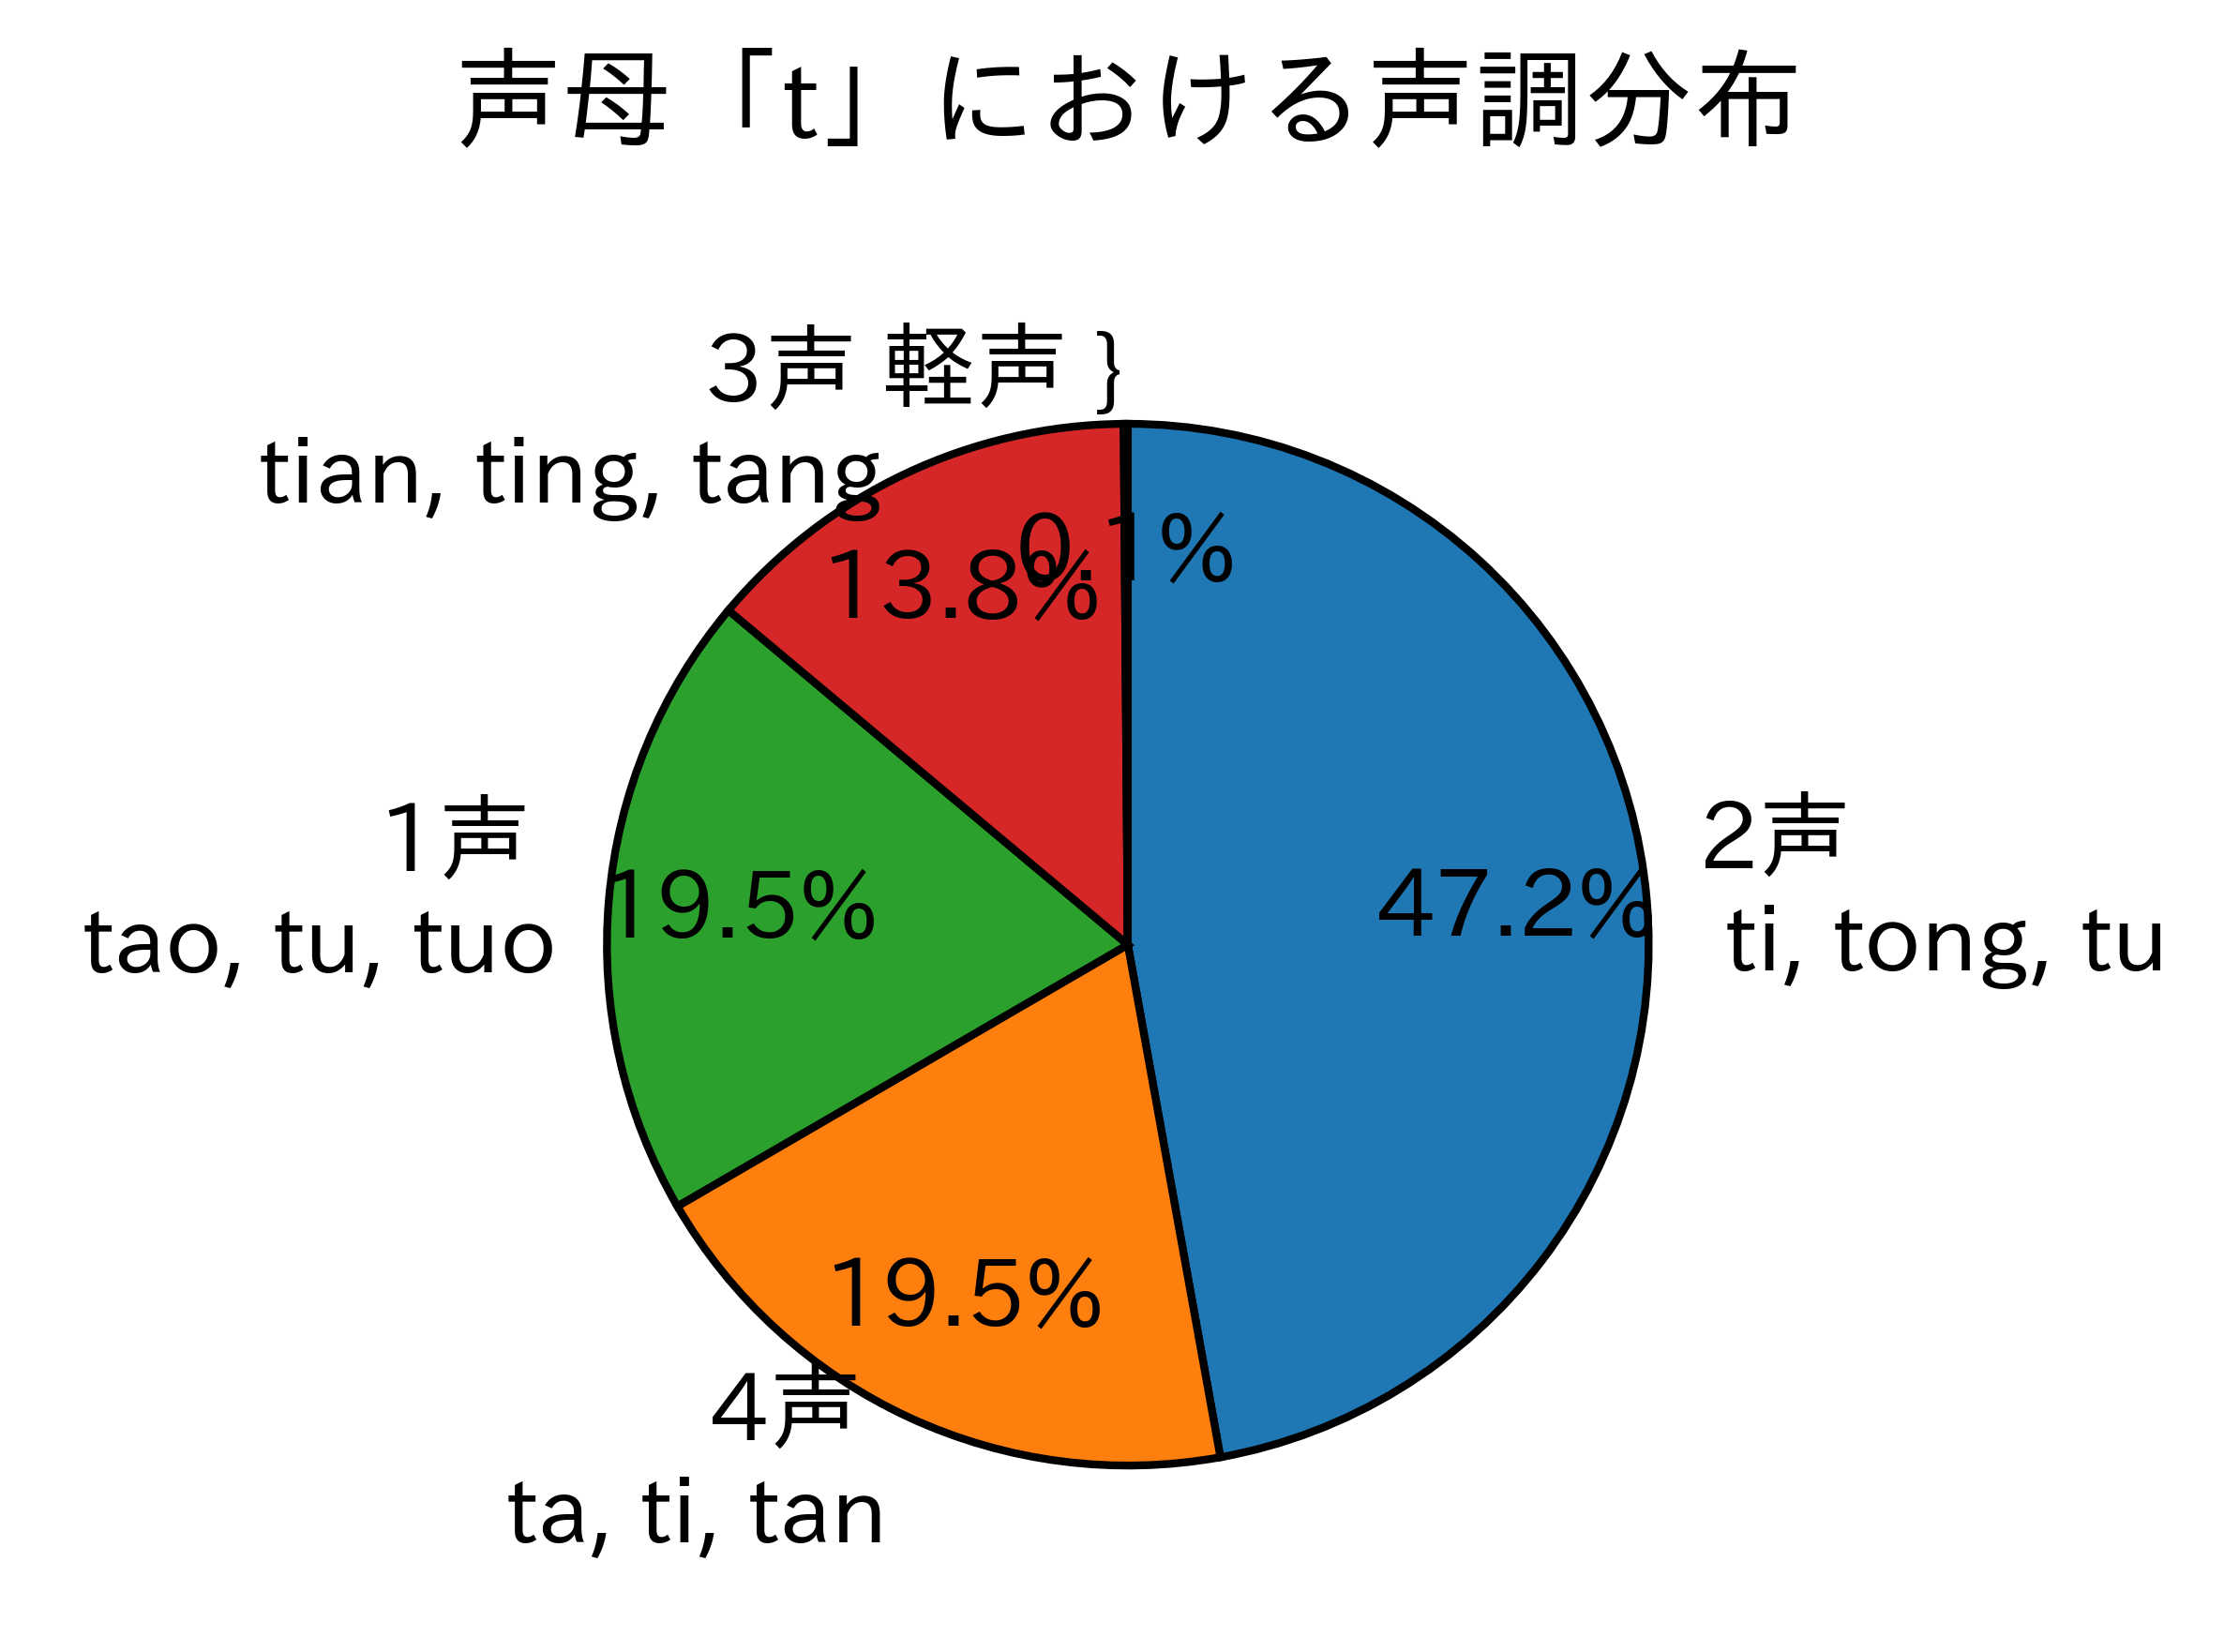

In [275]:
import matplotlib.pyplot as plt
import japanize_matplotlib
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

tone_labels = {
    1: f"1声 \n {examples[1]}",
    2: f"2声 \n {examples[2]}",
    3: f"3声 \n {examples[3]}",
    4: f"4声 \n {examples[4]}",
    5: "軽声 }",
}

fig, ax = plt.subplots(figsize=(4, 4), dpi=600)

wedges, texts, autotexts = ax.pie(
    tone_counts.values,
    labels=[tone_labels[x] for x in tone_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "linewidth": 1,
        "edgecolor": "black"
    }
)

ax.set_title(
    f"声母「{test_consonants}」における声調分布",
    pad=20
)

plt.tight_layout()
plt.show()

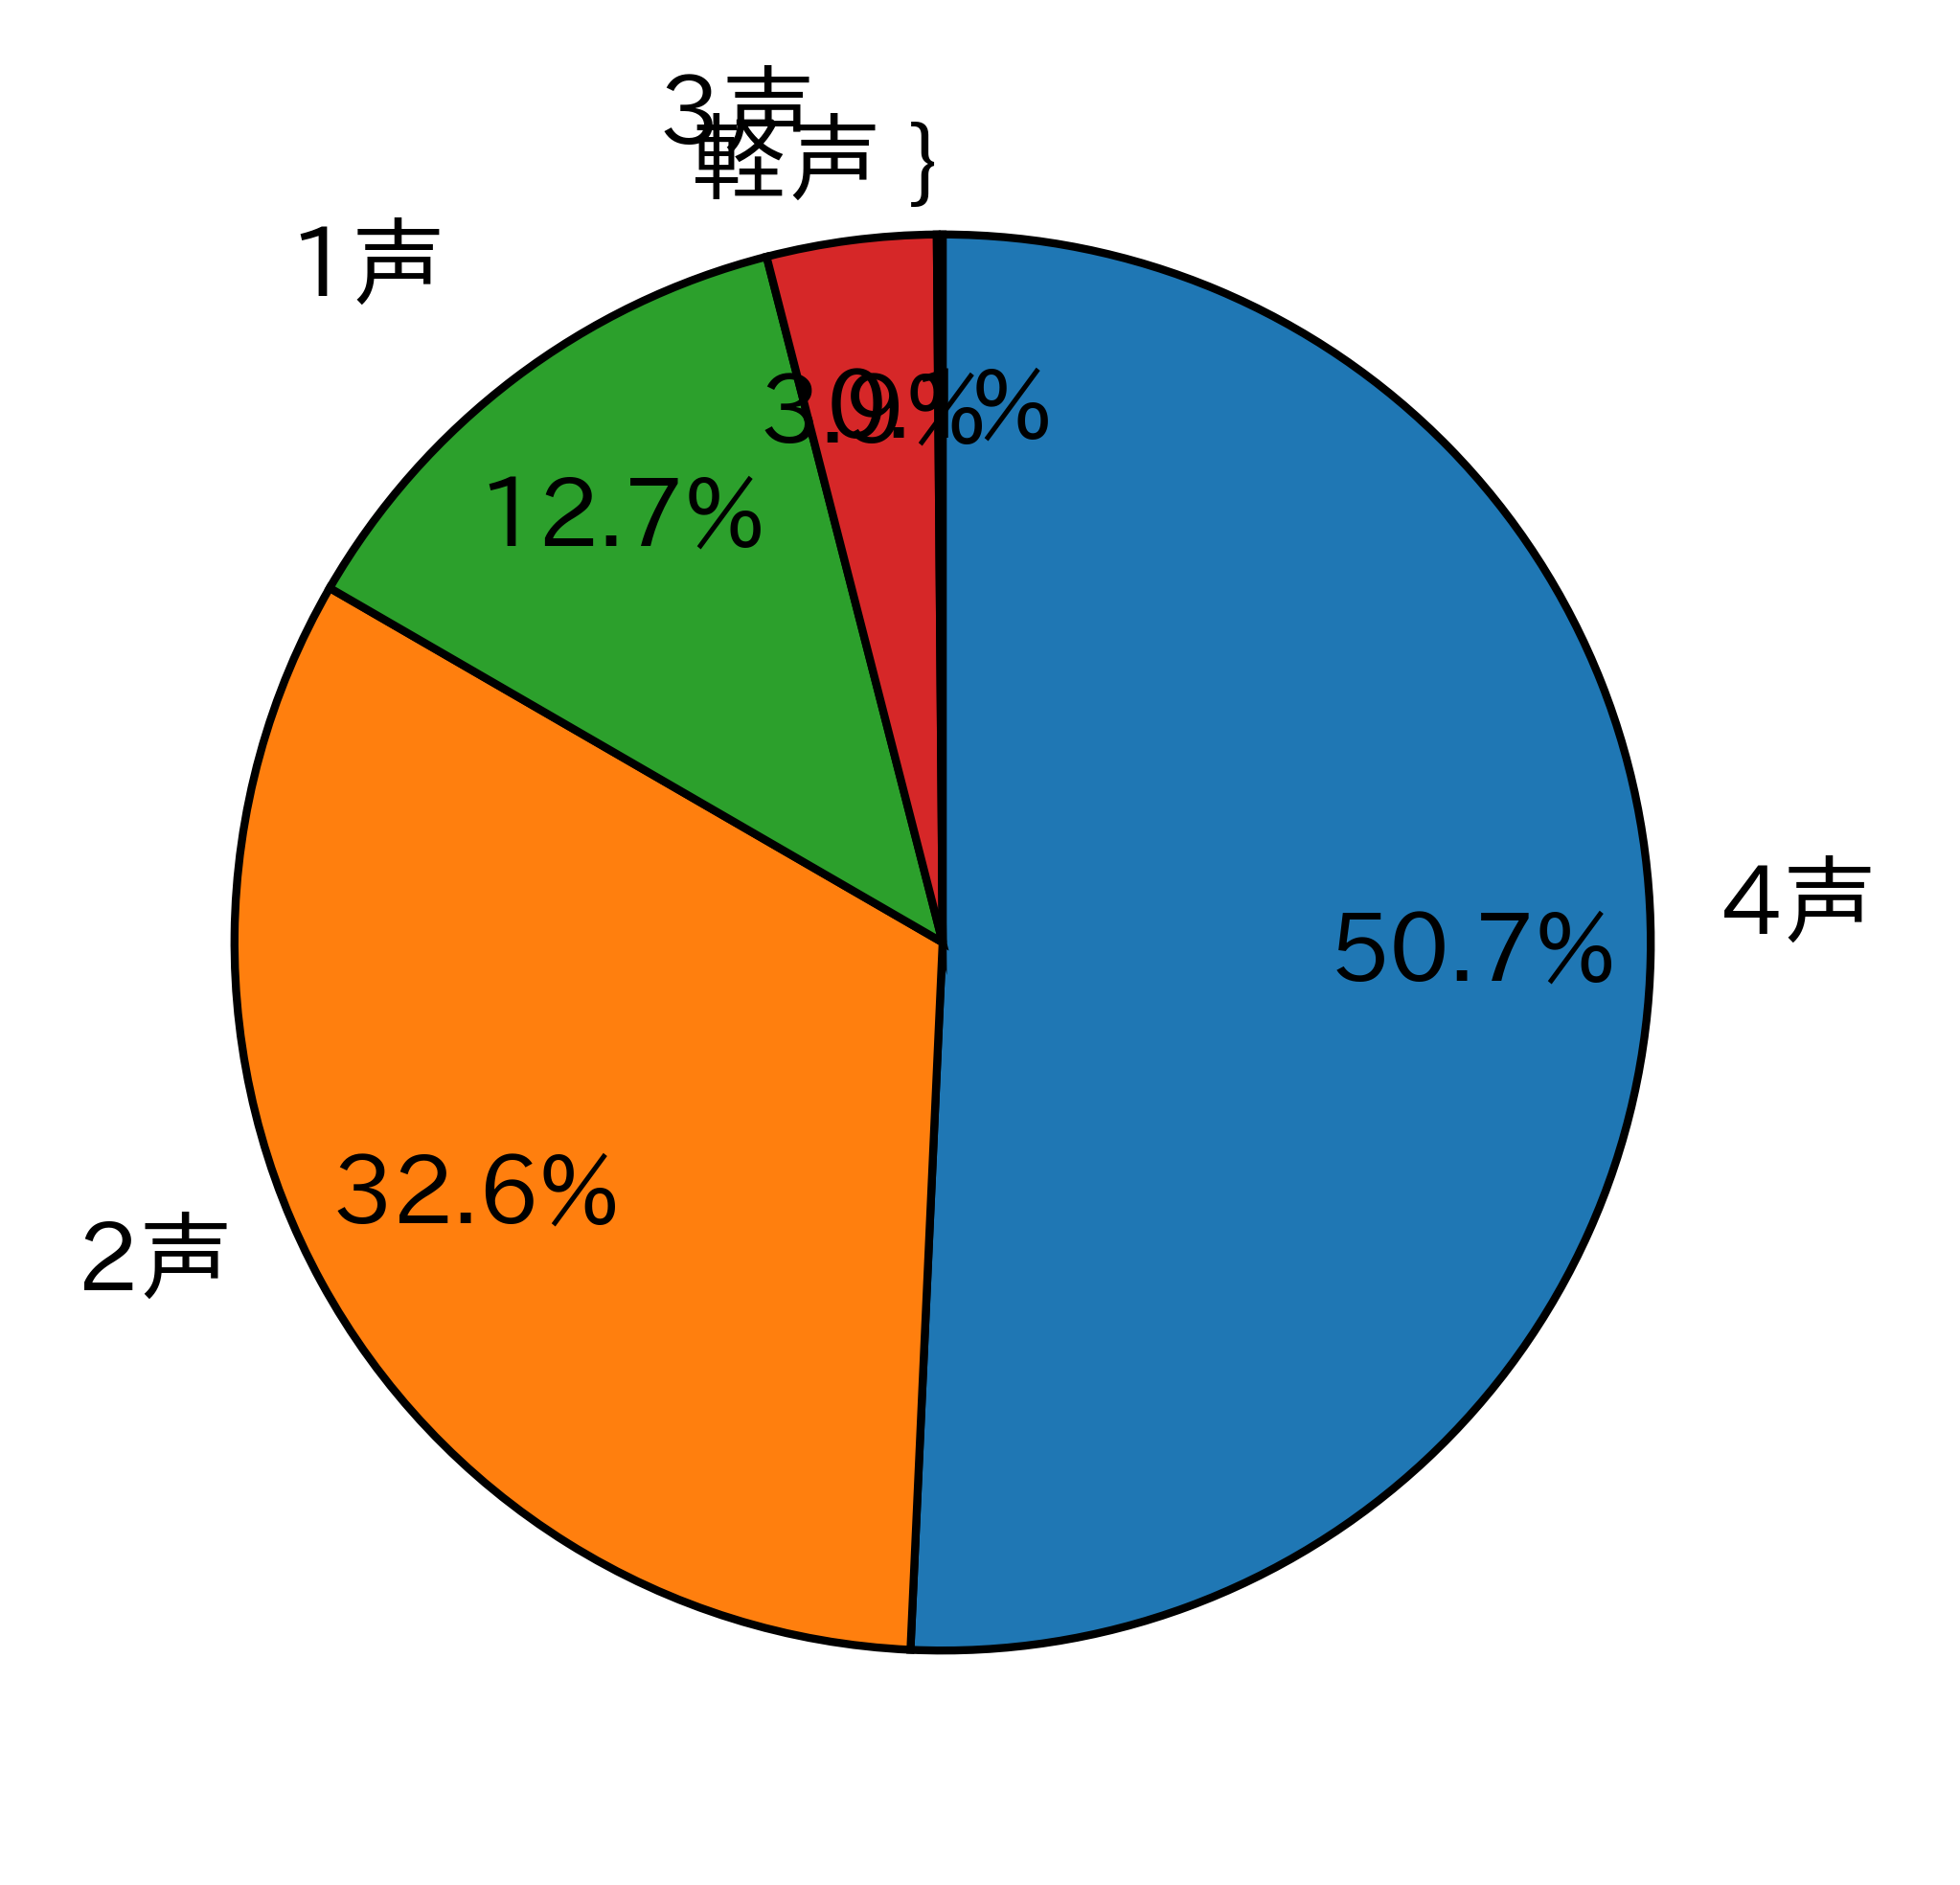

In [276]:
_df = df[df["middle_tone2"] == 4]

tone_counts = (
    _df["tone"]
    .value_counts()
)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

tone_labels = {
    1: f"1声 \n ",
    2: f"2声 \n",
    3: f"3声 \n",
    4: f"4声 \n",
    5: "軽声 }",
}

fig, ax = plt.subplots(figsize=(4, 4), dpi=600)

wedges, texts, autotexts = ax.pie(
    tone_counts.values,
    labels=[tone_labels[x] for x in tone_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "linewidth": 1,
        "edgecolor": "black"
    }
)

/tmp/ipykernel_4809/2264418726.py:103: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  left[i] + pct/2,


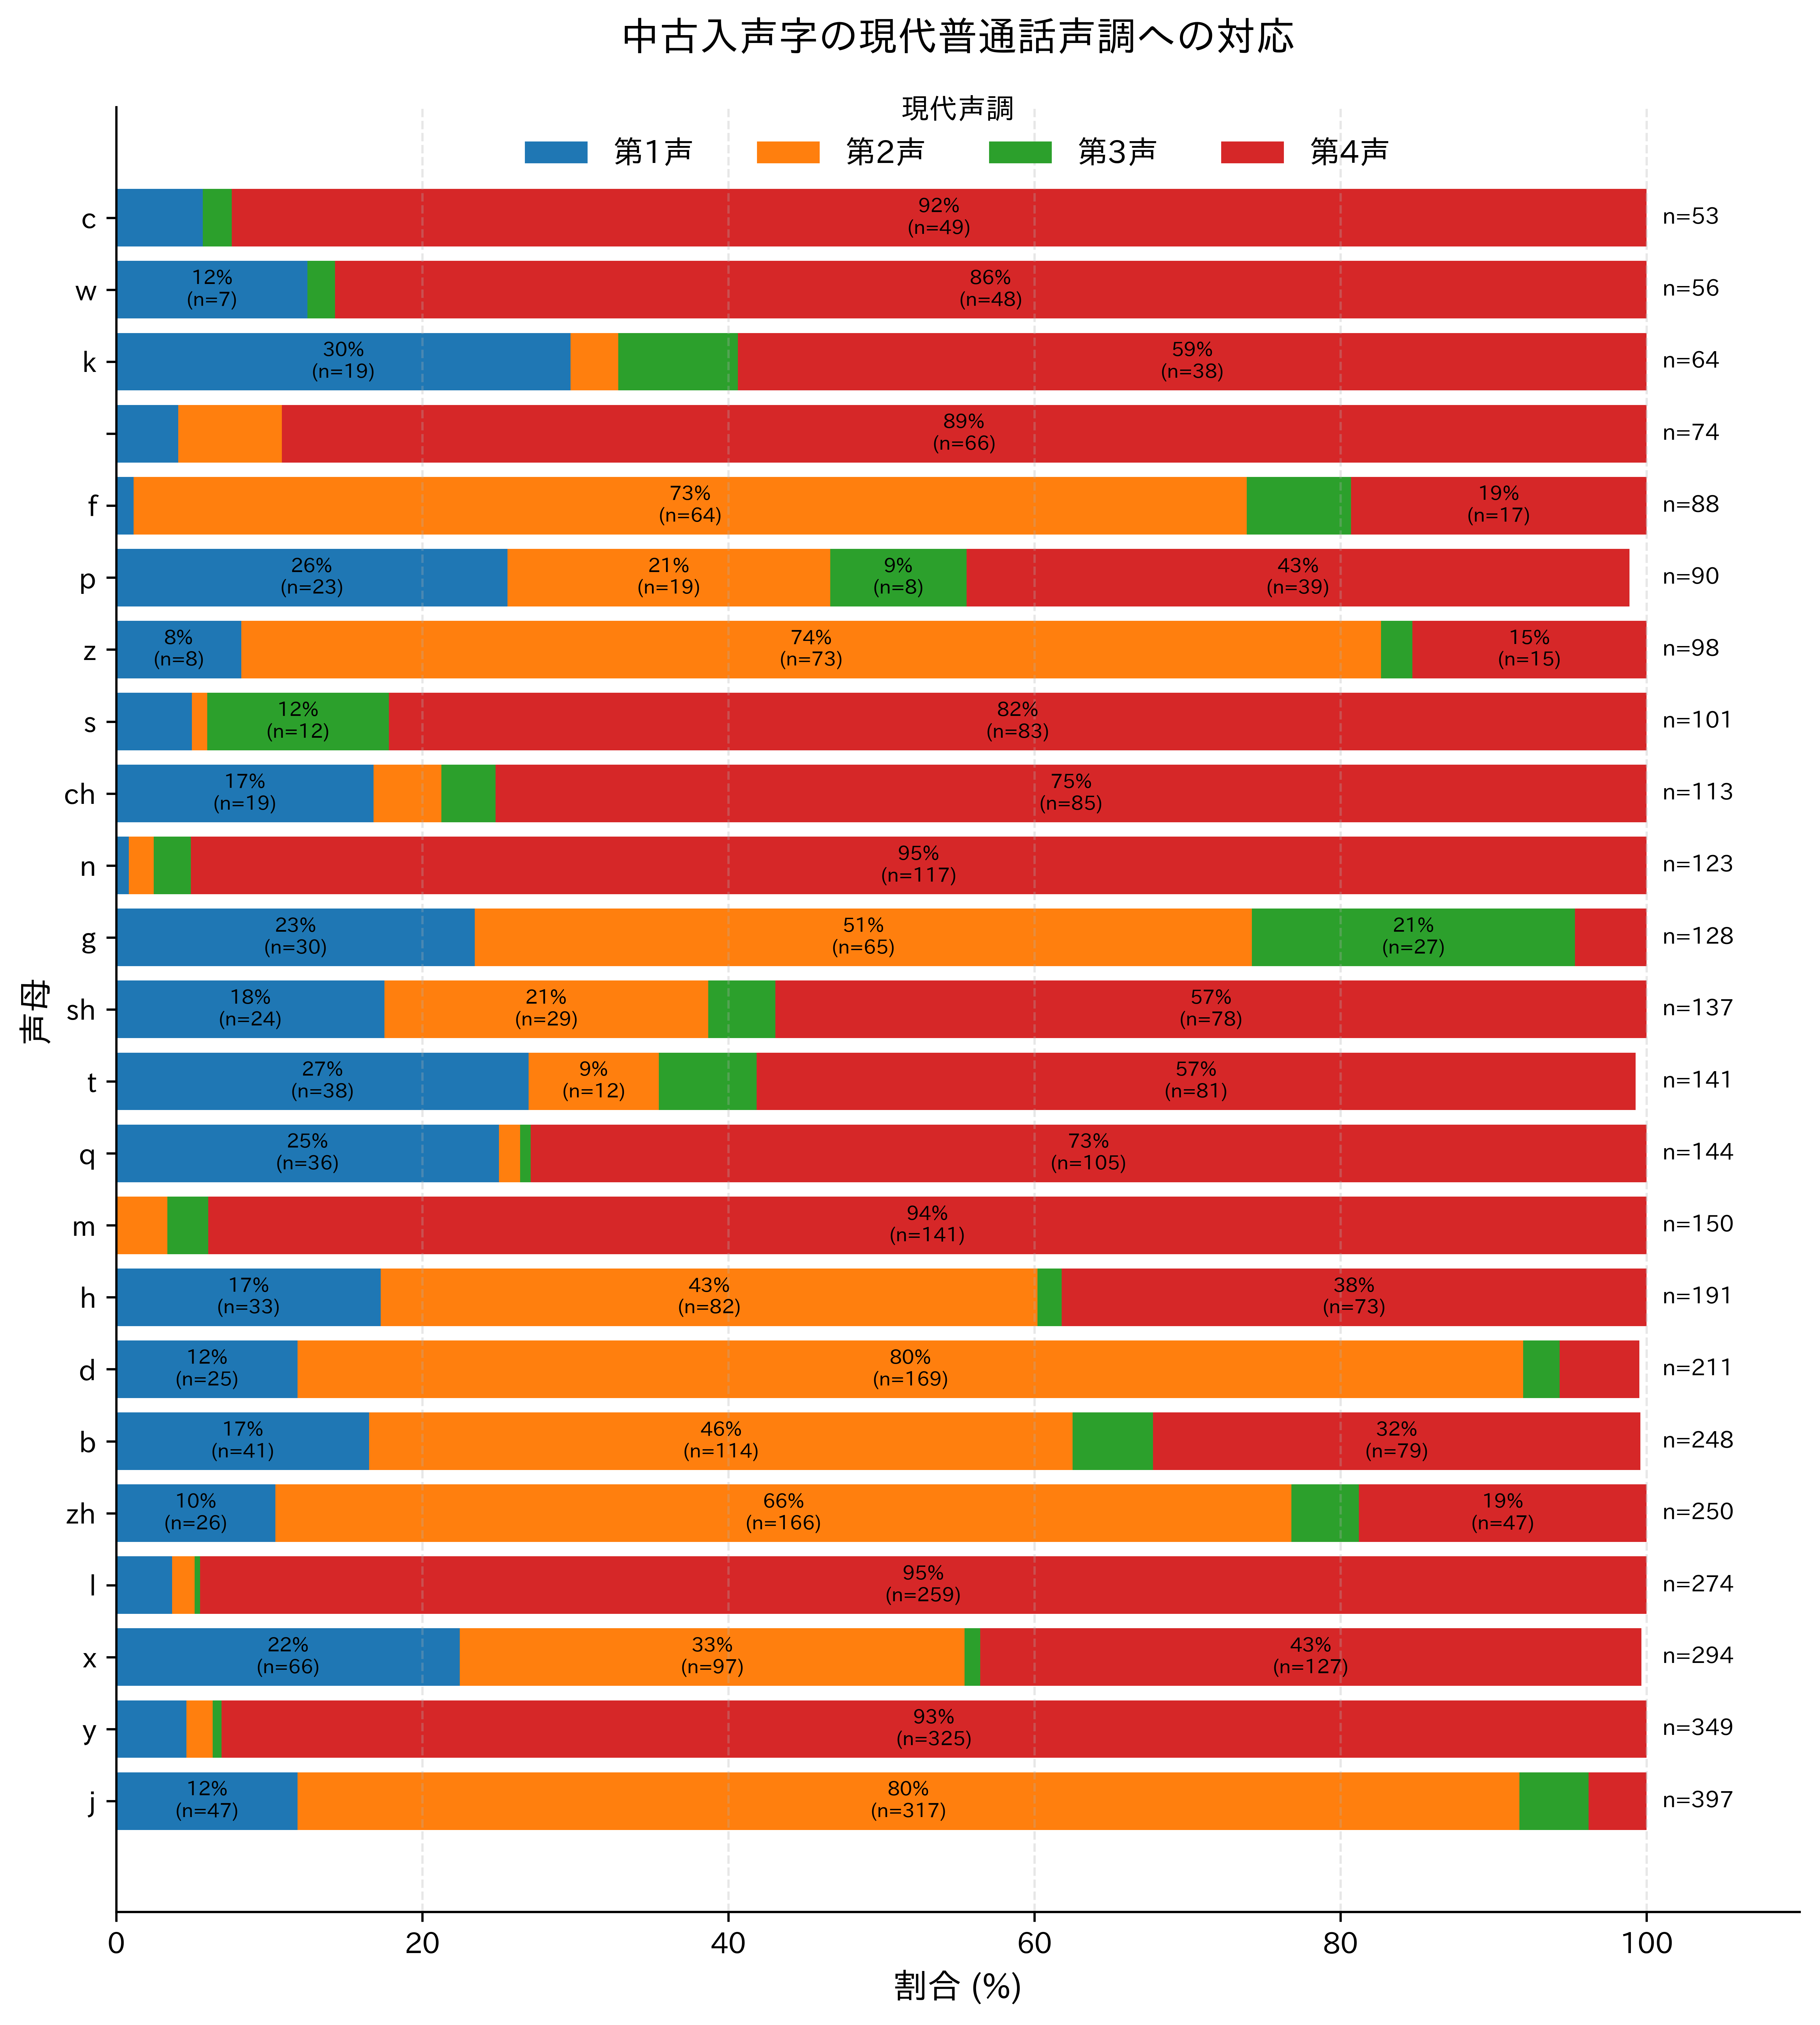

In [279]:
import matplotlib.pyplot as plt
import japanize_matplotlib

# ========================
# 中古入声のみ
# ========================

subset = df[df["middle_tone2"] == 4].copy()

# ========================
# 声母 × 現代声調
# ========================

ct = pd.crosstab(
    subset["consonants"],
    subset["tone"]
)

# 出現数が少なすぎる声母は除外
MIN_COUNT = 30

ct = ct.loc[
    ct.sum(axis=1) >= MIN_COUNT
]

# 総字数
totals = ct.sum(axis=1)

# 100%化
ct_pct = ct.div(
    totals,
    axis=0
) * 100

# 出現数順
order = totals.sort_values(
    ascending=False
).index

ct = ct.loc[order]
ct_pct = ct_pct.loc[order]
totals = totals.loc[order]

# 声調列を揃える
for tone in [1, 2, 3, 4]:

    if tone not in ct.columns:
        ct[tone] = 0
        ct_pct[tone] = 0

ct = ct[[1,2,3,4]]
ct_pct = ct_pct[[1,2,3,4]]

# ========================
# フォント
# ========================

plt.rcParams.update({
    "font.size": 10
})

# ========================
# 描画
# ========================

fig, ax = plt.subplots(
    figsize=(9, 10),
    dpi=600
)

left = np.zeros(len(ct_pct))

tone_labels = {
    1: "第1声",
    2: "第2声",
    3: "第3声",
    4: "第4声"
}

for tone in [1,2,3,4]:

    percentages = ct_pct[tone]
    counts = ct[tone]

    bars = ax.barh(
        ct_pct.index,
        percentages,
        left=left,
        label=tone_labels[tone]
    )

    # --------------------
    # バー内部に表示
    # --------------------

    for i, (pct, cnt) in enumerate(
        zip(percentages, counts)
    ):

        if pct >= 8:

            ax.text(
                left[i] + pct/2,
                i,
                f"{pct:.0f}%\n(n={cnt})",
                ha="center",
                va="center",
                fontsize=7
            )

    left += percentages

# ========================
# 総字数表示
# ========================

for i, total in enumerate(totals):

    ax.text(
        101,
        i,
        f"n={total}",
        va="center",
        fontsize=8
    )

# ========================
# 体裁
# ========================

ax.set_xlim(0, 110)

ax.set_xlabel("割合 (%)")
ax.set_ylabel("声母")

ax.set_title(
    "中古入声字の現代普通話声調への対応",
    fontsize=14,
    pad=20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="現代声調",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    loc="lower center"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [278]:
df

,漢字,ピンイン,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2
1,㐁,tiàn,t,ian,4,透覃一開,去,3
4,㐆,yǐn,y,in,3,影微三開,平,1
14,㐭,lǐn,l,in,3,來侵三開,上,2
18,㐱,zhěn,zh,en,3,章眞三開,上,2
19,㐲,dài,d,ai,4,定泰一開,去,3
...,...,...,...,...,...,...,...,...
41394,𪚁,lián,l,ian,2,來仙三開,平,1
41403,𪚝,lóng,l,ong,2,來鍾三開,平,1
41404,𪚠,lóng,l,ong,2,來鍾三開,平,1
41409,𪚮,rán,r,an,2,泥覃一開,平,1
